# 01 · Data exploration

**Goal of this notebook:** understand the raw data *before* building anything on it.
For each dataset we answer four questions:

1. **Grain**: what does one row represent?
2. **Key columns**: which fields matter for the project?
3. **Traps**: missing values, codes, mismatches that would silently break an analysis.
4. **Implication**: what the finding means for the pipeline and the model.

Every finding at the end is linked to a decision in [`docs/decisions.md`](../docs/decisions.md).

| Dataset | Source | Role |
|---|---|---|
| Hospital Readmissions Reduction Program (HRRP) | CMS | **Target**: Excess Readmission Ratio |
| Hospital General Information | CMS | Hospital profile |
| Patient survey (HCAHPS) – Hospital | CMS | Candidate drivers |
| PLACES – County Data | CDC | Community health context |

## Setup

The data is downloaded straight from the public APIs, so anyone can rerun this notebook.

**Why look up the download link every time?** CMS puts a changing code in each file's URL
(for example `.../a171bc36..._1770163617/FY_2026_...csv`) and the code changes with every
refresh. Hard-coding the link would break at the next quarterly update. Instead we ask the
CMS *metastore* API for the current link, using the dataset's permanent ID (e.g. `9n3s-kdb3`).

Files are cached in `data/raw/` (ignored by Git) so reruns don't download again.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

RAW = Path("../data/raw")
RAW.mkdir(parents=True, exist_ok=True)
IMAGES = Path("../images")
IMAGES.mkdir(exist_ok=True)

CMS_METASTORE = "https://data.cms.gov/provider-data/api/1/metastore/schemas/dataset/items"

CMS_DATASETS = {                      # permanent dataset IDs on data.cms.gov
    "hrrp": "9n3s-kdb3",              # Hospital Readmissions Reduction Program
    "hospital_info": "xubh-q36u",     # Hospital General Information
    "hcahps": "dgck-syfz",            # Patient survey (HCAHPS) - Hospital
    "footnotes": "y9us-9xdf",         # Footnote Crosswalk (what each footnote code means)
}


def load_cms(name: str) -> pd.DataFrame:
    # Look up the current download link, download once, and read every column as text.
    meta = requests.get(f"{CMS_METASTORE}/{CMS_DATASETS[name]}", timeout=60).json()
    path = RAW / f"{name}.csv"
    if not path.exists():
        with requests.get(meta["distribution"][0]["downloadURL"], stream=True, timeout=300) as r:
            r.raise_for_status()
            with open(path, "wb") as f:
                for chunk in r.iter_content(chunk_size=1 << 20):
                    f.write(chunk)
    print(f"{name:14s} {meta['title']!r:55s} last updated {meta['modified']}")
    return pd.read_csv(path, dtype=str)


hrrp = load_cms("hrrp")
hospital_info = load_cms("hospital_info")
hcahps = load_cms("hcahps")
footnotes = load_cms("footnotes")

hrrp           'Hospital Readmissions Reduction Program'               last updated 2026-01-26


hospital_info  'Hospital General Information'                          last updated 2026-07-22


hcahps         'Patient survey (HCAHPS) - Hospital'                    last updated 2026-07-22


footnotes      'Footnote Crosswalk'                                    last updated 2025-09-18


**Why read every column as text (`dtype=str`)?** Two reasons:

- **Hospital IDs have leading zeros.** `010001` is a real ID; read as a number it becomes
  `10001` and no longer joins to other files.
- **Number columns contain words.** `Number of Readmissions` contains values like
  `Too Few to Report`. We convert to numbers deliberately, one column at a time, so every
  conversion is visible.

In [2]:
# Shared chart style: recessive axes, one accent colour, text in neutral ink.
BLUE, ORANGE, INK, MUTED, GRID = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": MUTED, "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlecolor": INK, "axes.titlelocation": "left",
    "font.size": 10,
})

CONDITIONS = {
    "READM-30-AMI-HRRP": "Heart attack (AMI)",
    "READM-30-HF-HRRP": "Heart failure",
    "READM-30-PN-HRRP": "Pneumonia",
    "READM-30-COPD-HRRP": "COPD",
    "READM-30-HIP-KNEE-HRRP": "Hip/knee replacement",
    "READM-30-CABG-HRRP": "Bypass surgery (CABG)",
}

## 1 · HRRP: the target

### Grain
We expect **one row per hospital per condition**. Checking the grain first matters: if a
hospital-condition pair appeared twice, every later join and average would be quietly wrong.

In [3]:
print(f"rows: {len(hrrp):,}   hospitals: {hrrp['Facility ID'].nunique():,}   conditions: {hrrp['Measure Name'].nunique()}")
dupes = hrrp.duplicated(["Facility ID", "Measure Name"]).sum()
print(f"duplicate hospital x condition rows: {dupes}")
hrrp.head(3)

rows: 18,330   hospitals: 3,055   conditions: 6
duplicate hospital x condition rows: 0


,Facility Name,Facility ID,State,Measure Name,Number of Discharges,Footnote,Excess Readmission Ratio,Predicted Readmission Rate,Expected Readmission Rate,Number of Readmissions,Start Date,End Date
0,SOUTHEAST HEALTH MEDICAL CENTER,010001,AL,READM-30-HIP-KNEE-HRRP,NaN,NaN,0.9875,4.5734,4.6311,Too Few to Report,07/01/2021,06/30/2024
1,SOUTHEAST HEALTH MEDICAL CENTER,010001,AL,READM-30-CABG-HRRP,137,NaN,0.9531,10.3960,10.9078,13,07/01/2021,06/30/2024
2,SOUTHEAST HEALTH MEDICAL CENTER,010001,AL,READM-30-AMI-HRRP,273,NaN,0.9370,13.2998,14.1948,33,07/01/2021,06/30/2024


### Key columns

| Column | Meaning |
|---|---|
| `Predicted Readmission Rate` | Rate this hospital is expected to have, given its own patients |
| `Expected Readmission Rate` | Rate an *average* hospital would have with the same patients |
| **`Excess Readmission Ratio` (ERR)** | Predicted ÷ Expected. **Above 1.0 = more readmissions than expected** |
| `Footnote` | Code explaining why a value is missing |
| `Start Date` / `End Date` | The discharge period the numbers cover |

CMS risk-adjusts ERR for how sick each hospital's patients are, so a hospital that treats
sicker patients is not penalised for that alone.

**How the penalty is actually decided.** Since fiscal year 2019 (21st Century Cures Act) the
line is **not** 1.0. CMS places hospitals in **five peer groups** by their share of patients who
are eligible for both Medicare and Medicaid, a marker of lower-income patients, and compares
each hospital's ERR with the **median ERR of its peer group**:

> penalty for a condition = neutrality modifier × DRG payment ratio × (ERR − peer-group median ERR)

The total is capped at 3% of Medicare base payments. The peer group is not in this file, so
the ingestion step adds CMS's HRRP supplemental data (Decision D-014).

In [4]:
hrrp["err"] = pd.to_numeric(hrrp["Excess Readmission Ratio"], errors="coerce")
hrrp["condition"] = hrrp["Measure Name"].map(CONDITIONS)
hrrp["err"].describe().round(3)

count    11720.000
mean         1.002
std          0.082
min          0.470
25%          0.958
50%          0.997
75%          1.042
max          1.630
Name: err, dtype: float64

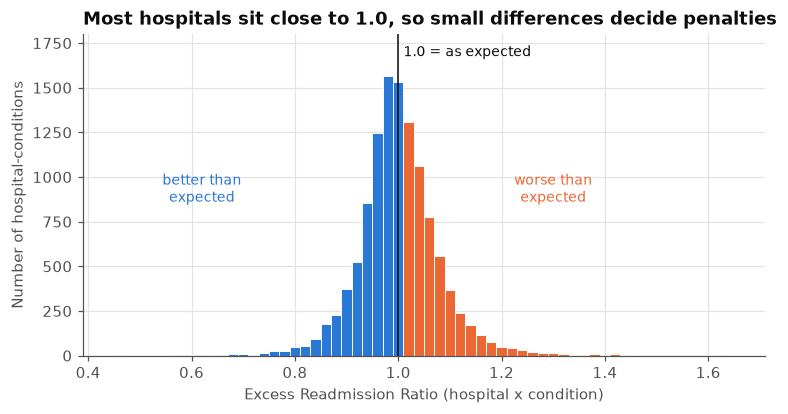

middle 50% of scored rows: 0.958 to 1.042


In [5]:
scored = hrrp["err"].dropna()
bins = np.arange(0.45, 1.66, 0.02)
fig, ax = plt.subplots(figsize=(8, 3.8))
counts, edges, patches = ax.hist(scored, bins=bins, edgecolor="white", linewidth=0.6)
for patch, left in zip(patches, edges[:-1]):
    patch.set_facecolor(ORANGE if left >= 1.0 else BLUE)
ax.axvline(1.0, color=INK, linewidth=1)
ax.set_ylim(0, counts.max() * 1.15)
ax.text(1.01, counts.max() * 1.07, "1.0 = as expected", color=INK, fontsize=9)
ax.text(0.62, counts.max() * 0.55, "better than\nexpected", color=BLUE, fontsize=9, ha="center")
ax.text(1.30, counts.max() * 0.55, "worse than\nexpected", color=ORANGE, fontsize=9, ha="center")
ax.set_title("Most hospitals sit close to 1.0, so small differences decide penalties")
ax.set_xlabel("Excess Readmission Ratio (hospital x condition)")
ax.set_ylabel("Number of hospital-conditions")
fig.savefig(IMAGES / "01_err_distribution.png")
plt.show()

print(f"middle 50% of scored rows: {scored.quantile(.25):.3f} to {scored.quantile(.75):.3f}")

**What we see:** ERR clusters tightly around 1.0; half of all scores fall between about
0.96 and 1.04. A hospital at 1.03 and one at 0.97 look similar, but they sit on opposite sides
of the penalty line. The model has to be precise in a narrow range, which is one reason to
validate it carefully (step 7).

### Which conditions are worst? A trap in the obvious calculation

The tempting calculation is "share of hospitals above 1.0, per condition". But if hospitals
**without** a score stay in the denominator, conditions with many missing values look better
than they are. We compute it only over hospitals that have a score, and look at coverage
separately.

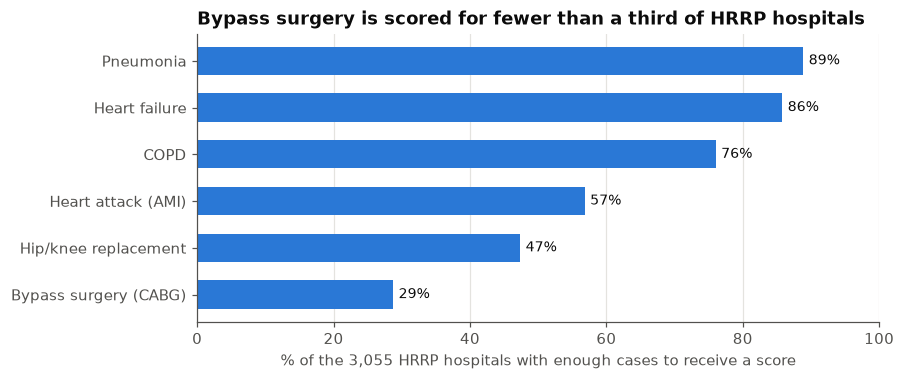

hospitals above 1.0 on at least one condition: 2,358 of 3,055 (77%)


,hospitals_scored,mean_err,share_above_1_of_scored,coverage
condition,,,,
Bypass surgery (CABG),878,1.002,0.499,0.287
Hip/knee replacement,1447,1.004,0.479,0.474
Heart attack (AMI),1736,1.002,0.497,0.568
COPD,2323,1.001,0.472,0.760
Heart failure,2621,1.001,0.489,0.858
Pneumonia,2715,1.001,0.468,0.889


In [6]:
n_hospitals = hrrp["Facility ID"].nunique()
by_condition = (
    hrrp.groupby("condition")["err"]
    .agg(hospitals_scored="count", mean_err="mean",
         share_above_1_of_scored=lambda s: (s.dropna() > 1).mean())
    .assign(coverage=lambda d: d["hospitals_scored"] / n_hospitals)
    .sort_values("coverage")
)

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.barh(by_condition.index, by_condition["coverage"] * 100, color=BLUE, height=0.6)
for y, v in enumerate(by_condition["coverage"] * 100):
    ax.text(v + 0.8, y, f"{v:.0f}%", va="center", color=INK, fontsize=9)
ax.set_title("Bypass surgery is scored for fewer than a third of HRRP hospitals")
ax.set_xlabel(f"% of the {n_hospitals:,} HRRP hospitals with enough cases to receive a score")
ax.set_xlim(0, 100)
ax.grid(axis="y", visible=False)
fig.savefig(IMAGES / "02_scored_coverage_by_condition.png")
plt.show()

per_hospital = hrrp.groupby("Facility ID")["err"].apply(lambda s: (s > 1).any())
print(f"hospitals above 1.0 on at least one condition: {per_hospital.sum():,} of {len(per_hospital):,} "
      f"({per_hospital.mean():.0%})")
by_condition.round(3)

**What we see:**

- Among hospitals that have a score, **about half are above 1.0 for every condition**, and the
  average ERR is about 1.00 everywhere. That is by design: ERR compares each hospital with what
  an average hospital would achieve, so roughly half land on each side. **The share above 1.0
  cannot tell us which condition is "worst".** The better question is where the most money is
  lost, which needs payment data (a later step).
- What differs is **coverage**: pneumonia and heart failure are scored at most hospitals, while
  bypass surgery is scored at under a third, because only larger hospitals perform enough
  of them.
- About three in four hospitals are above 1.0 on at least one condition. Part of that is
  arithmetic: with a coin-flip chance on each of several conditions, most hospitals land above
  1.0 somewhere. Penalties are therefore common, which makes *how much* and *why* more useful
  questions than *who*.

### Trap: missing values are *reasons*, not zeros

In [7]:
fn_text = footnotes.set_index("Footnote")["Footnote Text"]
missing = hrrp[hrrp["err"].isna()]
print(f"rows without an ERR: {len(missing):,} of {len(hrrp):,} ({len(missing) / len(hrrp):.0%})")
(
    missing["Footnote"].fillna("(none)").value_counts().rename("rows").to_frame()
    .assign(meaning=lambda d: d.index.map(fn_text))
)

rows without an ERR: 6,610 of 18,330 (36%)


,rows,meaning
Footnote,,
5,3255,Results are not available for this reporting p...
1,3150,The number of cases/patients is too few to rep...
7,205,No cases met the criteria for this measure.


**What we see:** over a third of rows have no ERR, and CMS says why: mostly *too few cases to
report* (small hospitals) or *results not available*. If these were filled with 0, those
hospitals would look like they had **zero readmissions**, the best score possible, and the model
would learn that small hospitals are excellent.

➡ **Decision D-003:** keep missing as missing, carry the footnote reason alongside it.

## 2 · Hospital General Information: the hospital profile

**Grain:** one row per hospital (including hospitals that are not part of HRRP).

In [8]:
print(f"hospitals: {len(hospital_info):,}   duplicate IDs: {hospital_info['Facility ID'].duplicated().sum()}")
hrrp_ids = set(hrrp["Facility ID"])
in_hrrp = hospital_info[hospital_info["Facility ID"].isin(hrrp_ids)]

pd.DataFrame({
    "all hospitals": hospital_info["Hospital Type"].value_counts(),
    "in HRRP": in_hrrp["Hospital Type"].value_counts(),
}).fillna(0).astype(int)

hospitals: 5,419   duplicate IDs: 0


,all hospitals,in HRRP
Hospital Type,,
Acute Care - Department of Defense,32,0
Acute Care - Veterans Administration,132,0
Acute Care Hospitals,3107,3035
Childrens,94,0
Critical Access Hospitals,1382,0
Long-term,5,0
Psychiatric,624,0
Rural Emergency Hospital,43,0


**What we see:** HRRP covers essentially only **acute care hospitals**. Critical access
hospitals (small rural hospitals), psychiatric and children's hospitals are exempt from the
program, so they are out of scope for the model (Decision D-002).

In [9]:
missing_from_info = hrrp_ids - set(hospital_info["Facility ID"])
print(f"HRRP hospitals with no row in General Information: {len(missing_from_info)}")
print("star rating availability among HRRP hospitals:")
in_hrrp["Hospital overall rating"].value_counts()

HRRP hospitals with no row in General Information: 20
star rating availability among HRRP hospitals:


Hospital overall rating
3                846
4                779
2                569
Not Available    381
5                290
1                170
Name: count, dtype: int64

**What we see:**
- A few HRRP hospitals have **no profile row**, most likely hospitals that closed or merged
  after the readmission period. The pipeline must report them (a test), not drop them silently.
- Many hospitals show **"Not Available"** for the star rating: another missing value that must
  not become a number.

## 3 · HCAHPS patient survey: candidate drivers

**Grain:** one row per hospital per survey *answer*. That is why the file has about 325,000
rows. Most rows are answer percentages ("always", "usually", "sometimes or never"). For
modelling we only need the **linear mean scores**: one 0–100 summary score per topic per
hospital.

In [10]:
linear = hcahps[hcahps["HCAHPS Measure ID"].str.endswith("LINEAR_SCORE")].copy()
linear["score"] = pd.to_numeric(linear["HCAHPS Linear Mean Value"], errors="coerce")
print(f"all rows: {len(hcahps):,}   linear-score rows: {len(linear):,}")

(
    linear.groupby(["HCAHPS Measure ID", "HCAHPS Question"])["score"]
    .agg(hospitals="count", mean="mean", min="min", max="max")
    .round(1)
)

all rows: 325,720   linear-score rows: 38,320


,,hospitals,mean,min,max
HCAHPS Measure ID,HCAHPS Question,,,,
H_CLEAN_LINEAR_SCORE,Cleanliness - linear mean score,3183,86.6,70.0,99.0
H_COMP_1_LINEAR_SCORE,Nurse communication - linear mean score,3183,91.3,74.0,100.0
H_COMP_2_LINEAR_SCORE,Doctor communication - linear mean score,3183,90.7,75.0,100.0
H_COMP_5_LINEAR_SCORE,Communication about medicines - linear mean score,3183,77.0,57.0,95.0
H_COMP_6_LINEAR_SCORE,Discharge information - linear mean score,3183,85.6,64.0,100.0
H_HSP_RATING_LINEAR_SCORE,Overall hospital rating - linear mean score,3183,87.9,69.0,98.0
H_QUIET_LINEAR_SCORE,Quietness - linear mean score,3183,81.2,56.0,98.0
H_RECMND_LINEAR_SCORE,Recommend hospital - linear mean score,3183,87.0,61.0,98.0


**What we see:** eight topic scores per hospital. Scores are high and close together
(discharge information averages about 86 out of 100), so, like ERR, the useful signal is in
small differences.

## 4 · Trap: the time periods don't line up

Each file states the period its numbers cover. Before combining files, check that they
describe the **same time**.

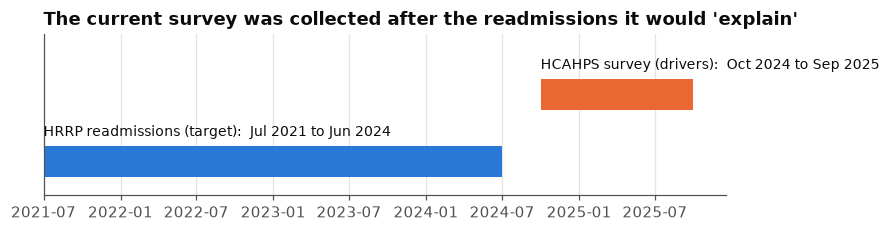

,dataset,start,end
0,HRRP readmissions (target),2021-07-01,2024-06-30
1,HCAHPS survey (drivers),2024-10-01,2025-09-30


In [11]:
periods = pd.DataFrame({
    "dataset": ["HRRP readmissions (target)", "HCAHPS survey (drivers)"],
    "start": [hrrp["Start Date"].iloc[0], hcahps["Start Date"].iloc[0]],
    "end": [hrrp["End Date"].iloc[0], hcahps["End Date"].iloc[0]],
})
periods[["start", "end"]] = periods[["start", "end"]].apply(pd.to_datetime, format="%m/%d/%Y")

fig, ax = plt.subplots(figsize=(8, 1.9))
for i, row in periods.iterrows():
    colour = BLUE if i == 0 else ORANGE
    ax.barh(i, row["end"] - row["start"], left=row["start"], height=0.45, color=colour)
    ax.text(row["start"], i + 0.38, f"{row['dataset']}:  {row['start']:%b %Y} to {row['end']:%b %Y}",
            color=INK, fontsize=9)
ax.set_yticks([])
ax.set_ylim(-0.5, 1.9)
ax.grid(axis="y", visible=False)
ax.set_title("The current survey was collected after the readmissions it would 'explain'")
fig.savefig(IMAGES / "03_period_mismatch.png")
plt.show()
periods

**What we see:** the readmissions happened **July 2021 – June 2024**; the current survey was
collected **October 2024 – September 2025**, *after* those patients were discharged.

Using later information to explain an earlier outcome is **data leakage**. The model would
score well in testing but could never work in real life, because at prediction time the future
survey doesn't exist yet.

➡ **Decision D-008:** use CMS's archived releases (step 6) so each hospital's survey scores come
from the same period as, or before, the readmissions.

## 5 · A first look at a driver: discharge information vs heart-failure readmissions

A quick sanity check that the drivers carry signal. **Caveat:** because of the period mismatch
above, this is only a rough look, not a result. Hospital survey scores change slowly, so a
relationship should still be visible.

We split hospitals into five groups (quintiles) by their *discharge information* score and
compare the average heart-failure ERR in each group. Scores are whole numbers and many
hospitals share the same score, so the groups are not exactly equal in size.

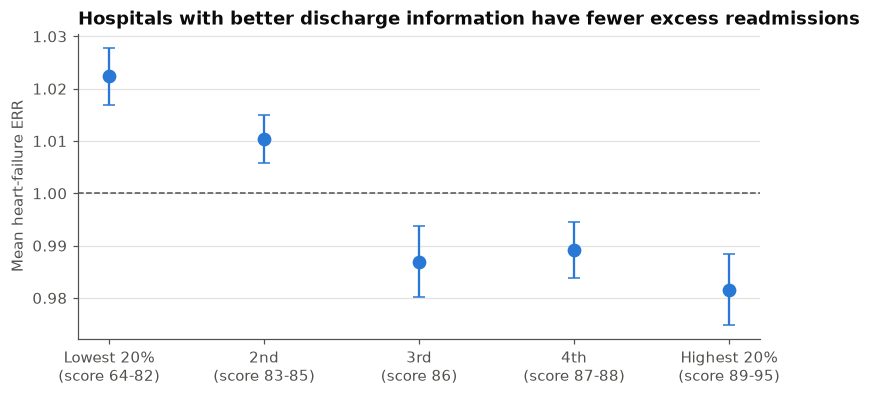

hospitals: 2,515   correlation: -0.23


,hospitals,mean_err,score_range,ci95
quintile,,,,
Lowest 20%,546,1.022,64-82,0.005
2nd,720,1.010,83-85,0.005
3rd,334,0.987,86,0.007
4th,566,0.989,87-88,0.005
Highest 20%,349,0.982,89-95,0.007


In [12]:
hf = hrrp.loc[hrrp["Measure Name"] == "READM-30-HF-HRRP", ["Facility ID", "err"]].dropna()
discharge = linear.loc[linear["HCAHPS Measure ID"] == "H_COMP_6_LINEAR_SCORE", ["Facility ID", "score"]].dropna()
joined = hf.merge(discharge, on="Facility ID")
joined["quintile"] = pd.qcut(joined["score"], 5, labels=["Lowest 20%", "2nd", "3rd", "4th", "Highest 20%"])

summary = joined.groupby("quintile", observed=True).agg(
    hospitals=("err", "size"), mean_err=("err", "mean"), sd=("err", "std"),
    score_range=("score", lambda s: f"{s.min():.0f}" if s.min() == s.max() else f"{s.min():.0f}-{s.max():.0f}"),
)
summary["ci95"] = 1.96 * summary["sd"] / np.sqrt(summary["hospitals"])

fig, ax = plt.subplots(figsize=(8, 3.6))
x = np.arange(len(summary))
ax.errorbar(x, summary["mean_err"], yerr=summary["ci95"], fmt="o", color=BLUE,
            markersize=8, capsize=4, linewidth=1.5)
ax.axhline(1.0, color=MUTED, linewidth=1, linestyle="--")
ax.set_xticks(x, [f"{q}\n(score {r})" for q, r in zip(summary.index, summary["score_range"])])
ax.set_ylabel("Mean heart-failure ERR")
ax.set_title("Hospitals with better discharge information have fewer excess readmissions")
ax.grid(axis="x", visible=False)
fig.savefig(IMAGES / "04_discharge_info_vs_hf_err.png")
plt.show()

print(f"hospitals: {len(joined):,}   correlation: {joined['err'].corr(joined['score']):.2f}")
summary.drop(columns="sd").round(3)

**What we see:** average heart-failure ERR falls steadily from the lowest-scoring to the
highest-scoring group, and the error bars (95% confidence intervals) of the two extremes do not
overlap. The correlation is modest, so discharge information is **one driver among several**,
not the whole story.

**This is association, not causation.** Well-run hospitals may simply do many things well at
once. The model (step 7) will measure each driver while accounting for the others.

## 6 · Linking hospitals to their county (CDC PLACES)

CDC PLACES gives community health measures (diabetes, obesity, uninsured adults, lack of
transportation…) **per county**. To attach them to a hospital we need the hospital's county.

**The problem:** the hospital file has a county *name* (`HOUSTON`, state `AL`); PLACES has a
county *code* (FIPS `01069`) and a mixed-case name (`Houston`). We try the simplest approach
first, matching on state + cleaned-up name, and measure how well it works.

In [13]:
import re

places_counties = pd.DataFrame(requests.get(
    "https://data.cdc.gov/resource/swc5-untb.json",
    params={"$select": "stateabbr,locationname,locationid",
            "$group": "stateabbr,locationname,locationid", "$limit": 10000},
    timeout=60,
).json())
print(f"PLACES counties: {len(places_counties):,}")


def clean_county(name: str) -> str:
    # Upper-case, drop punctuation, 'SAINT' -> 'ST', and drop words like COUNTY / PARISH.
    s = re.sub(r"[.'\u2019]", "", str(name).upper().strip()).replace("SAINT ", "ST ")
    s = re.sub(r"\s+(COUNTY|PARISH|BOROUGH|CENSUS AREA|MUNICIPALITY|CITY AND BOROUGH)$", "", s)
    return re.sub(r"\s+", " ", s)


places_counties["key"] = places_counties["stateabbr"] + "|" + places_counties["locationname"].map(clean_county)
hospitals = in_hrrp[["Facility ID", "State", "County/Parish"]].copy()
hospitals["key"] = hospitals["State"] + "|" + hospitals["County/Parish"].map(clean_county)

matched = hospitals.merge(places_counties.drop_duplicates("key")[["key", "locationid"]], on="key", how="left")
print(f"HRRP hospitals matched to a county: {matched['locationid'].notna().sum():,} of {len(matched):,} "
      f"({matched['locationid'].notna().mean():.1%})")

PLACES counties: 3,145
HRRP hospitals matched to a county: 2,912 of 3,035 (95.9%)


In [14]:
print("Most common unmatched counties:")
matched.loc[matched["locationid"].isna(), ["State", "County/Parish"]].value_counts().head(12)

Most common unmatched counties:


State  County/Parish 
MD     BALTIMORE CITY    11
LA     E. BATON ROUGE     8
CT     HARTFORD           6
       NEW HAVEN          6
       FAIRFIELD          6
DC     THE DISTRICT       6
IL     DU PAGE            6
VA     RICHMOND CITY      4
GA     DE KALB            3
NM     DONA ANA           3
CT     WINDHAM            2
       LITCHFIELD         2
Name: count, dtype: int64

In [15]:
ambiguous = places_counties[places_counties.duplicated("key", keep=False)].sort_values("key")
print("County names that exist twice in the same state (a county and an independent city):")
ambiguous[["stateabbr", "locationname", "locationid"]]

County names that exist twice in the same state (a county and an independent city):


,stateabbr,locationname,locationid
1197,MD,Baltimore,24005
1218,MD,Baltimore,24510
1580,MO,St. Louis,29189
1599,MO,St. Louis,29510
2850,VA,Fairfax,51059
2926,VA,Fairfax,51600
2854,VA,Franklin,51067
2928,VA,Franklin,51620
2897,VA,Richmond,51159
2946,VA,Richmond,51760


**What we see:** simple name cleanup links about **96%** of hospitals, and the failures follow
clear patterns:

- **Spelling variants:** `DU PAGE` vs `DuPage`, `MC HENRY` vs `McHenry`, `E. BATON ROUGE`.
- **Connecticut:** since 2022 the Census uses *planning regions* instead of counties in
  Connecticut, so CT county names don't exist in PLACES at all.
- **Independent cities:** *Baltimore* is both a county (`24005`) and a separate city (`24510`)
  with the same name. This is the most dangerous case: a name match can **silently pick the
  wrong one**, and no error would ever appear.

➡ **Implication for step 5:** matching on names is not reliable enough for production. Step 5
will use a more robust key, such as the hospital's ZIP code mapped to a county code through a
public Census crosswalk, and a test will report the match rate on every run.

## Summary: what the data told us and what we do about it

| # | Finding | What we do | Decision |
|---|---|---|---|
| 1 | ERR clusters tightly around 1.0; small differences decide penalties | Validate the model carefully on precision near 1.0 | D-009 |
| 2 | Penalties compare ERR with the **peer-group median**, not 1.0; peer groups are not in this file | Add CMS's HRRP supplemental data at ingestion | D-014 |
| 3 | About half of scored hospitals are above 1.0 for *every* condition (by design); conditions differ in coverage, not severity | Rank conditions by money at stake, not by share above 1.0 | D-002 |
| 4 | Over a third of ERR values are missing, each with a stated reason | Keep as missing, carry the reason, never fill with 0 | D-003 |
| 5 | HRRP covers essentially only acute care hospitals; 20 have no profile row | Scope to acute care; test for unmatched hospitals | D-002 |
| 6 | The current survey comes *after* the readmission period | Use archived releases to align periods (no leakage) | D-008 |
| 7 | Better discharge information goes with fewer heart-failure readmissions (association) | Include survey scores as drivers; test properly in the model | D-009 |
| 8 | Name-based county matching reaches ~96% but can silently pick the wrong county | Use a code-based crosswalk plus a match-rate test | Step 5 |

**Next step (3):** turn the download code above into a proper ingestion module that saves raw
files, records when each was downloaded, and skips files that haven't changed.